## Deep FM model for Search Relevance Ranking

In [ ]:
import pickle
import cloudpickle
from tqdm import tqdm
import random
import os

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
from sklearn.metrics import roc_auc_score, log_loss

import torch
from torch.utils.data import Dataset, DataLoader

import json
from datetime import datetime

from deepctr_torch.models import DeepFM
from deepctr_torch.inputs import SparseFeat, DenseFeat, get_feature_names
from deepctr_torch.callbacks import EarlyStopping


In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

## Data Loading & Preparation

In [5]:
df = pd.read_pickle('../pickle_files/df_features_enriched.pkl')
print(df.shape)
print(df.dtypes)
print(df.memory_usage(deep=True).sum() / 1e6, "MB")

(54281, 31)
answers                   object
passages                  object
query                        str
query_id                   int32
query_type                   str
wellFormedAnswers         object
passage_text                 str
is_selected               object
label                      int64
query_length               int64
passage_length             int64
length_ratio             float64
exact_match                int64
query_term_coverage      float64
jaccard_similarity       float64
tfidf_cosine_sim         float64
bm25_score               float64
passage_position           int64
idf_weighted_coverage    float64
bigram_overlap           float64
trigram_overlap          float64
passage_has_number         int64
query_has_number           int64
both_have_number           int64
is_numeric                 int64
is_description             int64
is_entity                  int64
numeric_x_has_number       int64
description_x_length       int64
entity_x_exact_match       int6

### Features

In [6]:

df['query_type_encoded'] = LabelEncoder().fit_transform(df['query_type'].astype(str))

In [7]:
# Columns not to use as features: query, passage_text. passages, answers, wellFormedanswers, is_selected
# Columns to keep but not as features: query_id, label

# Dense Feat - continuous or numerical features
# Sparse Features - categorical features

dense_features = [
    'query_length', 'passage_length', 'length_ratio',
    'exact_match', 'query_term_coverage', 'jaccard_similarity',
    'tfidf_cosine_sim', 'bm25_score', 'passage_position',
    'idf_weighted_coverage', 'bigram_overlap', 'trigram_overlap',
    'passage_has_number', 'query_has_number', 'both_have_number',
    'is_numeric', 'is_description', 'is_entity',
    'numeric_x_has_number', 'description_x_length', 'entity_x_exact_match',
    'max_tfidf_term'
]

sparse_features = [
  'query_type_encoded'
]

### Tran Test Split

In [8]:
unique_qids = df['query_id'].unique()

train_qids, temp_qids = train_test_split(
    unique_qids, test_size=0.30, random_state=42
)
val_qids, test_qids = train_test_split(
    temp_qids, test_size=0.50, random_state=42
)

train_df = df[df['query_id'].isin(train_qids)].reset_index(drop=True).copy()
val_df   = df[df['query_id'].isin(val_qids)].reset_index(drop=True).copy()
test_df  = df[df['query_id'].isin(test_qids)].reset_index(drop=True).copy()

print(f"Train shape: {train_df.shape}")
print(f"Val shape:   {val_df.shape}")
print(f"Test shape:  {test_df.shape}")

Train shape: (37986, 32)
Val shape:   (8149, 32)
Test shape:  (8146, 32)


### Scaling

In [9]:
scaler = StandardScaler()
train_df[dense_features] = scaler.fit_transform(train_df[dense_features])
val_df[dense_features]   = scaler.transform(val_df[dense_features])
test_df[dense_features]  = scaler.transform(test_df[dense_features])

with open('../pickle_files/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

In [10]:
fixlen_feature_columns = (
    [SparseFeat(feat, vocabulary_size=df[feat].nunique() + 1, embedding_dim=4)
     for feat in sparse_features]
    +
    [DenseFeat(feat, 1) for feat in dense_features]
)

feature_names = get_feature_names(fixlen_feature_columns)
print(f"Feature Names: {feature_names}")

Feature Names: ['query_type_encoded', 'query_length', 'passage_length', 'length_ratio', 'exact_match', 'query_term_coverage', 'jaccard_similarity', 'tfidf_cosine_sim', 'bm25_score', 'passage_position', 'idf_weighted_coverage', 'bigram_overlap', 'trigram_overlap', 'passage_has_number', 'query_has_number', 'both_have_number', 'is_numeric', 'is_description', 'is_entity', 'numeric_x_has_number', 'description_x_length', 'entity_x_exact_match', 'max_tfidf_term']


### Preparing Input in Deepctr Torch Format


In [11]:
# Build inputs
def build_input(data, feature_names):
    return {name: data[name].values for name in feature_names}

train_input = build_input(train_df, feature_names)
val_input   = build_input(val_df, feature_names)
test_input  = build_input(test_df, feature_names)

y_train = train_df['label'].values.astype(np.float32)
y_val   = val_df['label'].values.astype(np.float32)
y_test  = test_df['label'].values.astype(np.float32)


## DeepFM Model

In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

set_seed(42) 
model = DeepFM(
    linear_feature_columns=fixlen_feature_columns,
    dnn_feature_columns=fixlen_feature_columns,
    dnn_hidden_units=(128, 64, 32),
    dnn_dropout=0.3,
    task='binary',
    device=device
)

model.compile(
    optimizer='adam',
    # optimizer='adagrad', 
    loss='binary_crossentropy',
    metrics = ['binary_crossentropy', 'auc']
)

print(model)

Using device: cpu
DeepFM(
  (embedding_dict): ModuleDict(
    (query_type_encoded): Embedding(6, 4)
  )
  (linear_model): Linear(
    (embedding_dict): ModuleDict(
      (query_type_encoded): Embedding(6, 1)
    )
  )
  (out): PredictionLayer()
  (fm): FM()
  (dnn): DNN(
    (dropout): Dropout(p=0.3, inplace=False)
    (linears): ModuleList(
      (0): Linear(in_features=26, out_features=128, bias=True)
      (1): Linear(in_features=128, out_features=64, bias=True)
      (2): Linear(in_features=64, out_features=32, bias=True)
    )
    (activation_layers): ModuleList(
      (0-2): 3 x ReLU(inplace=True)
    )
  )
  (dnn_linear): Linear(in_features=32, out_features=1, bias=False)
)


### Model Training

In [13]:
history = model.fit(
    train_input, 
    y_train,
    batch_size=256,
    epochs = 20,
    # validation_split = 0.1,
    validation_data=(val_input, y_val),
    verbose = 1
)

torch.save(model.state_dict(), '../models/deepfm_best.pt')
# torch.save(model, '../models/deepfm_best.pt')
print("Model saved to deepfm_best.pt")

cpu
Train on 37986 samples, validate on 8149 samples, 149 steps per epoch


149it [00:01, 109.21it/s]


Epoch 1/20
1s - loss:  0.4264 - binary_crossentropy:  0.4260 - auc:  0.6355 - val_binary_crossentropy:  0.3242 - val_auc:  0.6665


149it [00:00, 178.84it/s]


Epoch 2/20
0s - loss:  0.3207 - binary_crossentropy:  0.3209 - auc:  0.6790 - val_binary_crossentropy:  0.3233 - val_auc:  0.6691


...

Epoch 18/20
0s - loss:  0.3141 - binary_crossentropy:  0.3147 - auc:  0.7046 - val_binary_crossentropy:  0.3186 - val_auc:  0.6894


149it [00:00, 194.08it/s]


Epoch 19/20
0s - loss:  0.3141 - binary_crossentropy:  0.3139 - auc:  0.7049 - val_binary_crossentropy:  0.3184 - val_auc:  0.6917


149it [00:00, 193.57it/s]


Epoch 20/20
0s - loss:  0.3138 - binary_crossentropy:  0.3138 - auc:  0.7069 - val_binary_crossentropy:  0.3187 - val_auc:  0.6895
Model saved to deepfm_best.pt


### Model Evaluation - Training and Test Metrics

In [14]:
test_preds = model.predict(test_input, batch_size=256).flatten()


test_auc  = roc_auc_score(y_test, test_preds)
test_loss = log_loss(y_test, test_preds)

print(f"Test Loss : {test_loss:.4f}")
print(f"Test AUC  : {test_auc:.4f}")

Test Loss : 0.3145
Test AUC  : 0.6977


### Model Evaluation - Ranking Metrics

In [15]:
def compute_ndcg_at_k(df_eval, preds, k=10):
    df_eval = df_eval.copy()
    df_eval["pred"] = preds
    ndcg_scores = []

    for query_id, group in df_eval.groupby("query_id"):
        group_sorted = group.sort_values("pred", ascending=False)
        relevance = group_sorted["label"].values[:k]

        dcg = sum(rel / np.log2(rank + 2) for rank, rel in enumerate(relevance))

        ideal = group.sort_values("label", ascending=False)["label"].values[:k]
        idcg = sum(rel / np.log2(rank + 2) for rank, rel in enumerate(ideal))

        if idcg > 0:
            ndcg_scores.append(dcg / idcg)

    return float(np.mean(ndcg_scores)) if ndcg_scores else 0.0


def compute_map(df_eval, preds):
    df_eval = df_eval.copy()
    df_eval["pred"] = preds
    ap_scores = []

    for query_id, group in df_eval.groupby("query_id"):
        group_sorted = group.sort_values("pred", ascending=False)
        relevance = group_sorted["label"].values

        if relevance.sum() == 0:
            continue

        num_relevant = 0
        precisions = []

        for rank, rel in enumerate(relevance, start=1):
            if rel == 1:
                num_relevant += 1
                precisions.append(num_relevant / rank)

        ap_scores.append(np.mean(precisions))

    return float(np.mean(ap_scores)) if ap_scores else 0.0


def compute_mrr(df_eval, preds):
    df_eval = df_eval.copy()
    df_eval["pred"] = preds
    reciprocal_ranks = []

    for query_id, group in df_eval.groupby("query_id"):
        group_sorted = group.sort_values("pred", ascending=False)
        relevance = group_sorted["label"].values

        rr = 0.0
        for rank, rel in enumerate(relevance, start=1):
            if rel == 1:
                rr = 1.0 / rank
                break

        reciprocal_ranks.append(rr)

    return float(np.mean(reciprocal_ranks)) if reciprocal_ranks else 0.0


def compute_precision_at_k(df_eval, preds, k=10):
    df_eval = df_eval.copy()
    df_eval["pred"] = preds
    p_scores = []

    for query_id, group in df_eval.groupby("query_id"):
        group_sorted = group.sort_values("pred", ascending=False).head(k)
        relevance = group_sorted["label"].values

        denom = len(relevance)
        if denom > 0:
            p_scores.append(relevance.sum() / denom)

    return float(np.mean(p_scores)) if p_scores else 0.0

**Note to self: Update this to have the full metrics**

In [16]:
ncdg_10 = compute_ndcg_at_k(test_df, test_preds, k = 10)
map_score = compute_map(test_df, test_preds)

print("Ranking Evaluation Results")
# NDCG accounts for the graded relevance of results, providing a more nuanced understanding of Search Ranking Quality
print(f"NCDG 10 : {ncdg_10:.4f}")
print(f"MAP : {map_score:.4f}")


Ranking Evaluation Results
NCDG 10 : 0.6136
MAP : 0.4897


In [17]:
verify_preds = model.predict(test_input, batch_size=256).flatten()
verify_auc   = roc_auc_score(y_test, verify_preds)
verify_ndcg  = compute_ndcg_at_k(test_df, verify_preds, k=10)

print(f"Verification — Test AUC: {verify_auc:.4f} | NDCG@10: {verify_ndcg:.4f}")

Verification — Test AUC: 0.6977 | NDCG@10: 0.6136


## Training Curves

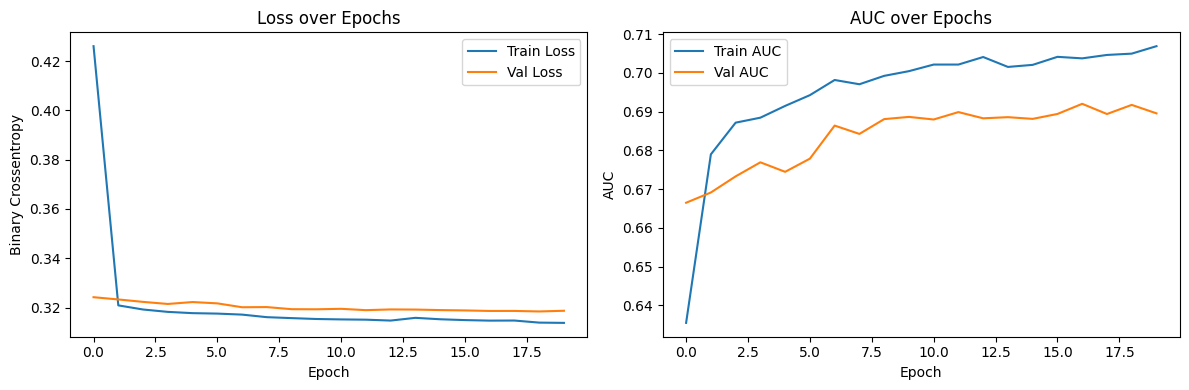

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.epoch, history.history['binary_crossentropy'], label='Train Loss')
axes[0].plot(history.epoch, history.history['val_binary_crossentropy'], label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend()

axes[1].plot(history.epoch, history.history['auc'], label='Train AUC')
axes[1].plot(history.epoch, history.history['val_auc'], label='Val AUC')
axes[1].set_title('AUC over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()

plt.tight_layout()
plt.show()

## Sensitivity Analysis

Two analyses:
1. **Hyperparameter sensitivity** — vary DNN size and dropout; report val loss.
2. **Feature ablation** — train with one feature left out at a time; see how much each feature matters.

#### Hyperparameter Sensitivity

In [19]:
device = "cuda" if torch.cuda.is_available() else "cpu"
sensitivity_epochs = 20
batch_size = 256

configs = [
    {"dnn_hidden_units": (128, 64, 32), "dnn_dropout": 0.0},
    {"dnn_hidden_units": (128, 64, 32), "dnn_dropout": 0.1},
    {"dnn_hidden_units": (128, 64, 32), "dnn_dropout": 0.3},
    {"dnn_hidden_units": (128, 64, 32), "dnn_dropout": 0.5},
    {"dnn_hidden_units": (256, 128, 64), "dnn_dropout": 0.3}
]

hp_results = []

for cfg in configs:
    print(f"Running: {cfg}")

    set_seed(42)

    m = DeepFM(
        linear_feature_columns=fixlen_feature_columns,
        dnn_feature_columns=fixlen_feature_columns,
        task="binary",
        device=device,
        dnn_hidden_units=cfg["dnn_hidden_units"],
        dnn_dropout=cfg["dnn_dropout"],
    )

    m.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["binary_crossentropy", "auc"]
    )

    es = EarlyStopping(
        monitor="val_binary_crossentropy",
        patience=3
    )

    hist = m.fit(
        train_input,
        y_train,
        batch_size=batch_size,
        epochs=sensitivity_epochs,
        validation_data=(val_input, y_val),
        callbacks=[es],
        verbose=0
    )

    # Evaluate on validation only
    val_preds = m.predict(val_input, batch_size=256).flatten()

    val_auc   = roc_auc_score(y_val, val_preds)
    val_loss  = log_loss(y_val, val_preds)
    val_ndcg  = compute_ndcg_at_k(val_df, val_preds, k=10)
    val_map   = compute_map(val_df, val_preds)
    val_mrr   = compute_mrr(val_df, val_preds)
    val_p10   = compute_precision_at_k(val_df, val_preds, k=10)

    hp_results.append({
        "architecture": str(cfg["dnn_hidden_units"]),
        "dropout": cfg["dnn_dropout"],
        "val_loss": round(val_loss, 4),
        "val_auc": round(val_auc, 4),
        "val_ndcg@10": round(val_ndcg, 4),
        "val_map": round(val_map, 4),
        "val_mrr": round(val_mrr, 4),
        "val_precision@10": round(val_p10, 4),
    })

hp_df = pd.DataFrame(hp_results).sort_values(
    ["val_ndcg@10", "val_auc"],
    ascending=[False, False]
).reset_index(drop=True)

print("\nHyperparameter Sensitivity Analysis (validation only):")
display(hp_df)

Running: {'dnn_hidden_units': (128, 64, 32), 'dnn_dropout': 0.0}
cpu
Train on 37986 samples, validate on 8149 samples, 149 steps per epoch
Running: {'dnn_hidden_units': (128, 64, 32), 'dnn_dropout': 0.1}
cpu
Train on 37986 samples, validate on 8149 samples, 149 steps per epoch
Running: {'dnn_hidden_units': (128, 64, 32), 'dnn_dropout': 0.3}
cpu
Train on 37986 samples, validate on 8149 samples, 149 steps per epoch
Running: {'dnn_hidden_units': (128, 64, 32), 'dnn_dropout': 0.5}
cpu
Train on 37986 samples, validate on 8149 samples, 149 steps per epoch
Running: {'dnn_hidden_units': (256, 128, 64), 'dnn_dropout': 0.3}
cpu
Train on 37986 samples, validate on 8149 samples, 149 steps per epoch

Hyperparameter Sensitivity Analysis (validation only):


,architecture,dropout,val_loss,val_auc,val_ndcg@10,val_map,val_mrr,val_precision@10
0,"(128, 64, 32)",0.5,0.3188,0.6889,0.6059,0.4797,0.4832,0.1072
1,"(128, 64, 32)",0.3,0.3190,0.6881,0.6048,0.4784,0.4819,0.1072
2,"(256, 128, 64)",0.3,0.3200,0.6884,0.6046,0.4775,0.4824,0.1072
3,"(128, 64, 32)",0.1,0.3188,0.6890,0.6023,0.4745,0.4787,0.1072
4,"(128, 64, 32)",0.0,0.3194,0.6872,0.6002,0.4719,0.4763,0.1072


**Hyper-parameeter Sensitivity Insights - TBR**

- All four (128, 64, 32) dropout configurations (0.0–0.5) produced NDCG@10 within 0.005 of each other, confirming the model is robust to this hyperparameter
- Dropout=0.0 showed the weakest performance, suggesting some regularization is beneficial even with tabular features
- The larger (256, 128, 64) architecture was competitive (NDCG@10 0.6142) but did not meaningfully outperform the simpler (128, 64, 32) architecture, and adds unnecessary parameters for a 22-feature tabular input
- We selected (128, 64, 32) with dropout=0.3 as the final architecture based on its balance of performance, simplicity, and standard regularization practice

#### Feature Ablation on best architecture

In [20]:
set_seed(42)

m_baseline = DeepFM(
    linear_feature_columns=fixlen_feature_columns,
    dnn_feature_columns=fixlen_feature_columns,
    task="binary", device=device,
    dnn_hidden_units=(128, 64, 32),
    dnn_dropout=0.3
)
m_baseline.compile(optimizer="adam", loss="binary_crossentropy", metrics=["binary_crossentropy", "auc"])
m_baseline.fit(
    train_input, y_train,
    batch_size=256,
    epochs=10,                              # ← same as ablation
    validation_data=(val_input, y_val),
    verbose=0
)

baseline_preds = m_baseline.predict(val_input, batch_size=256).flatten()
baseline_ndcg  = compute_ndcg_at_k(val_df, baseline_preds, k=10)
baseline_map   = compute_map(val_df, baseline_preds)
baseline_auc   = roc_auc_score(y_val, baseline_preds)

print(f"Baseline (10 epochs, all 22 features):")
print(f"NDCG@10: {baseline_ndcg:.4f} | MAP: {baseline_map:.4f} | AUC: {baseline_auc:.4f}")
# Should be ~0.59-0.60, NOT 0.61

cpu
Train on 37986 samples, validate on 8149 samples, 149 steps per epoch
Baseline (10 epochs, all 22 features):
NDCG@10: 0.6032 | MAP: 0.4759 | AUC: 0.6886


In [21]:

ablation_epochs = 10

ablation_results = []

for dropped in dense_features:  # only ablate dense features — always keep sparse query_type_encoded
    print(f"Dropping: {dropped}")

    # Build feature columns without the dropped feature
    remaining_dense = [f for f in dense_features if f != dropped]

    ablation_feature_columns = (
        [SparseFeat(feat, vocabulary_size=df[feat].nunique() + 1, embedding_dim=4)
         for feat in sparse_features]  # sparse features always included
        +
        [DenseFeat(feat, 1) for feat in remaining_dense]
    )

    ablation_feature_names = get_feature_names(ablation_feature_columns)

    # Build inputs without dropped feature
    train_input_ab = {n: train_df[n].values for n in ablation_feature_names}
    val_input_ab   = {n: val_df[n].values   for n in ablation_feature_names}

    set_seed(42)
    # Train ablation model — same architecture as the best model
    m_ab = DeepFM(
        linear_feature_columns=ablation_feature_columns,
        dnn_feature_columns=ablation_feature_columns,
        task="binary",
        device=device,
        dnn_hidden_units=(128, 64, 32),
        dnn_dropout=0.3
    )

    m_ab.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["binary_crossentropy", "auc"]
    )

    m_ab.fit(
        train_input_ab, y_train,
        batch_size=256,
        epochs=ablation_epochs,
        validation_data=(val_input_ab, y_val),  # ← proper val set
        verbose=0
    )

    # Evaluate
    preds_ab  = m_ab.predict(val_input_ab, batch_size=256).flatten()
    ndcg_ab   = compute_ndcg_at_k(val_df, preds_ab, k=10)
    map_ab    = compute_map(val_df, preds_ab)
    auc_ab    = roc_auc_score(y_val, preds_ab)

    # Drops — positive value means feature was helping
    ndcg_drop = baseline_ndcg - ndcg_ab
    map_drop  = baseline_map  - map_ab
    auc_drop  = baseline_auc  - auc_ab

    ablation_results.append({
        "dropped_feature" : dropped,
        "ndcg@10"         : round(ndcg_ab,   4),
        "map"             : round(map_ab,     4),
        "auc"             : round(auc_ab,     4),
        "ndcg@10_drop"    : round(ndcg_drop,  4),
        "map_drop"        : round(map_drop,   4),
        "auc_drop"        : round(auc_drop,   4),
    })

    print(f"  NDCG@10: {ndcg_ab:.4f} (drop: {ndcg_drop:+.4f}) | MAP: {map_ab:.4f} (drop: {map_drop:+.4f})")

ablation_df = pd.DataFrame(ablation_results).sort_values("ndcg@10_drop", ascending=False)

print("\n Feature Ablation Results (sorted by NDCG@10 impact):")
print("Positive drop = feature helps | Negative drop = feature hurts when included")
print(ablation_df.to_string(index=False))

Dropping: query_length
cpu
Train on 37986 samples, validate on 8149 samples, 149 steps per epoch
  NDCG@10: 0.5978 (drop: +0.0054) | MAP: 0.4689 (drop: +0.0070)
Dropping: passage_length
cpu
Train on 37986 samples, validate on 8149 samples, 149 steps per epoch
  NDCG@10: 0.5962 (drop: +0.0070) | MAP: 0.4665 (drop: +0.0094)
Dropping: length_ratio
cpu
Train on 37986 samples, validate on 8149 samples, 149 steps per epoch
  NDCG@10: 0.5985 (drop: +0.0046) | MAP: 0.4698 (drop: +0.0061)
Dropping: exact_match
cpu
Train on 37986 samples, validate on 8149 samples, 149 steps per epoch
  NDCG@10: 0.6033 (drop: -0.0001) | MAP: 0.4762 (drop: -0.0003)
Dropping: query_term_coverage
cpu
Train on 37986 samples, validate on 8149 samples, 149 steps per epoch
  NDCG@10: 0.5969 (drop: +0.0063) | MAP: 0.4678 (drop: +0.0081)
Dropping: jaccard_similarity
cpu
Train on 37986 samples, validate on 8149 samples, 149 steps per epoch
  NDCG@10: 0.6009 (drop: +0.0023) | MAP: 0.4729 (drop: +0.0030)
Dropping: tfidf_cosi

In [22]:
ablation_df

,dropped_feature,ndcg@10,map,auc,ndcg@10_drop,map_drop,auc_drop
8,passage_position,0.5921,0.4617,0.6801,0.0111,0.0142,0.0085
1,passage_length,0.5962,0.4665,0.6870,0.0070,0.0094,0.0016
12,passage_has_number,0.5962,0.4670,0.6732,0.0069,0.0089,0.0155
20,entity_x_exact_match,0.5963,0.4671,0.6883,0.0068,0.0088,0.0003
9,idf_weighted_coverage,0.5965,0.4670,0.6867,0.0066,0.0089,0.0020
4,query_term_coverage,0.5969,0.4678,0.6865,0.0063,0.0081,0.0021
17,is_entity,0.5973,0.4684,0.6861,0.0059,0.0075,0.0025
16,is_description,0.5974,0.4683,0.6880,0.0057,0.0076,0.0007
15,is_numeric,0.5975,0.4688,0.6846,0.0056,0.0071,0.0040
0,query_length,0.5978,0.4689,0.6872,0.0054,0.0070,0.0014


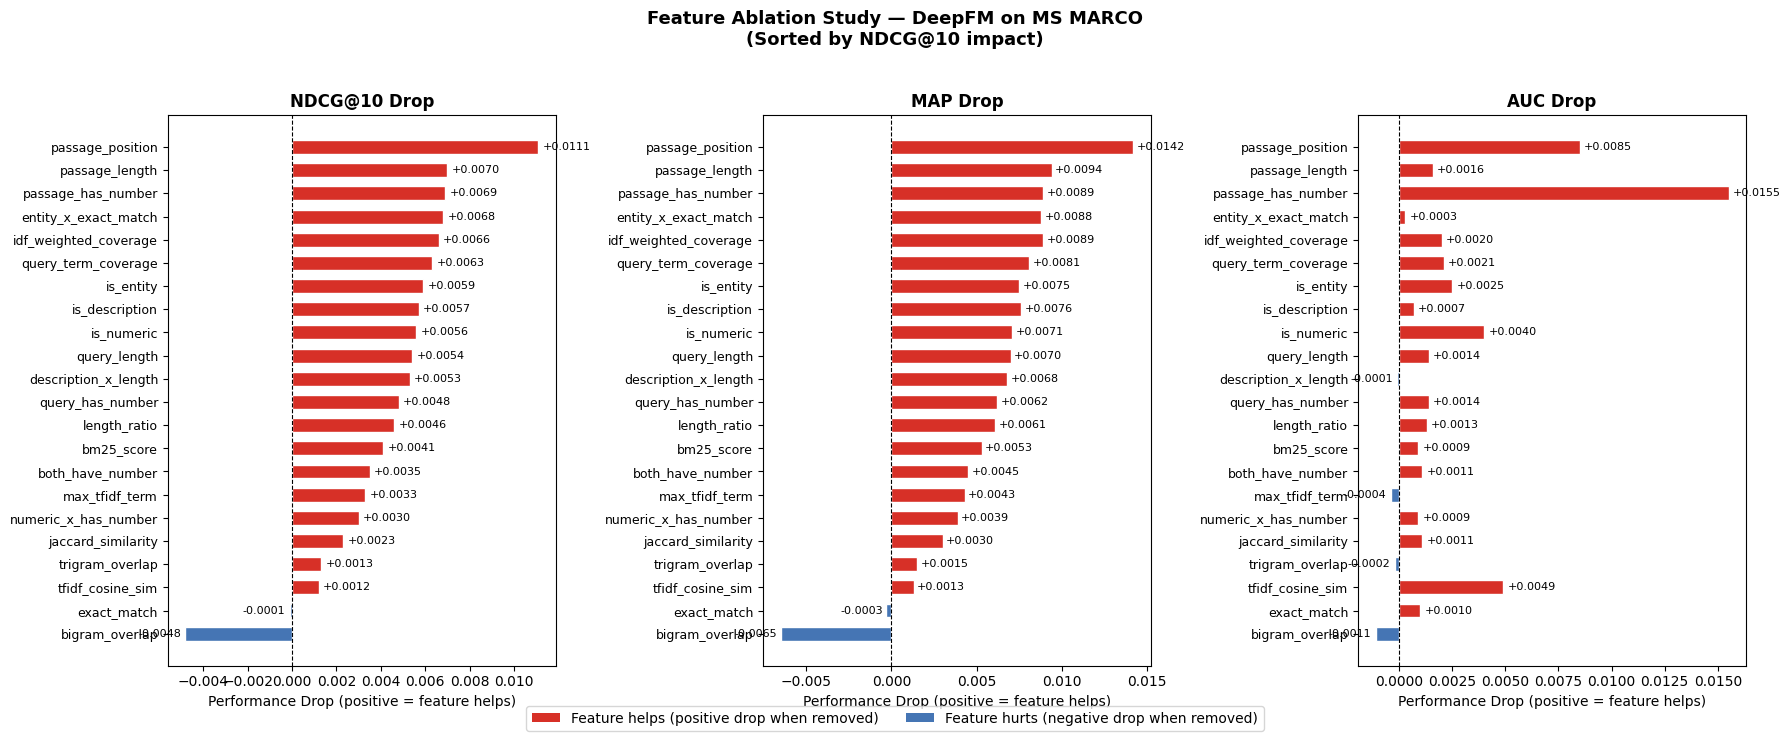

In [23]:
# Sort by NDCG@10 drop (most important feature first)
ablation_sorted = ablation_df.sort_values("ndcg@10_drop", ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

colors_ndcg = ['#d73027' if x > 0 else '#4575b4' for x in ablation_sorted["ndcg@10_drop"]]
colors_map  = ['#d73027' if x > 0 else '#4575b4' for x in ablation_sorted["map_drop"]]
colors_auc  = ['#d73027' if x > 0 else '#4575b4' for x in ablation_sorted["auc_drop"]]

y_pos = np.arange(len(ablation_sorted))

# NDCG@10 Drop 
axes[0].barh(y_pos, ablation_sorted["ndcg@10_drop"], color=colors_ndcg, edgecolor='white', height=0.6)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(ablation_sorted["dropped_feature"], fontsize=9)
axes[0].axvline(x=0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title("NDCG@10 Drop", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Performance Drop (positive = feature helps)")
for i, v in enumerate(ablation_sorted["ndcg@10_drop"]):
    axes[0].text(v + 0.0002 if v >= 0 else v - 0.0002, i,
                 f'{v:+.4f}', va='center', ha='left' if v >= 0 else 'right', fontsize=8)

# MAP Drop 
axes[1].barh(y_pos, ablation_sorted["map_drop"], color=colors_map, edgecolor='white', height=0.6)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(ablation_sorted["dropped_feature"], fontsize=9)
axes[1].axvline(x=0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title("MAP Drop", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Performance Drop (positive = feature helps)")
for i, v in enumerate(ablation_sorted["map_drop"]):
    axes[1].text(v + 0.0002 if v >= 0 else v - 0.0002, i,
                 f'{v:+.4f}', va='center', ha='left' if v >= 0 else 'right', fontsize=8)

# AUC Drop 
axes[2].barh(y_pos, ablation_sorted["auc_drop"], color=colors_auc, edgecolor='white', height=0.6)
axes[2].set_yticks(y_pos)
axes[2].set_yticklabels(ablation_sorted["dropped_feature"], fontsize=9)
axes[2].axvline(x=0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title("AUC Drop", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Performance Drop (positive = feature helps)")
for i, v in enumerate(ablation_sorted["auc_drop"]):
    axes[2].text(v + 0.0002 if v >= 0 else v - 0.0002, i,
                 f'{v:+.4f}', va='center', ha='left' if v >= 0 else 'right', fontsize=8)


from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d73027', label='Feature helps (positive drop when removed)'),
    Patch(facecolor='#4575b4', label='Feature hurts (negative drop when removed)')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Feature Ablation Study — DeepFM on MS MARCO\n(Sorted by NDCG@10 impact)',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

**Insights on Feature Ablation**

| Feature               | NDCG@10 Drop | Interpretation                                                     |
|-----------------------|-------------|--------------------------------------------------------------------|
| passage_position      | +0.0111    | Most important — structural position is a strong signal           |
| tfidf_cosine_sim      | +0.0015     | Second most important — vocabulary overlap matters                |
| passage_has_number    | +0.0006     | Small but positive — relevant for numeric queries                 |
| query_term_coverage   | +0.0001     | Marginal positive signal                                          |

Surprising finding: bm25_score has a negative drop. Removing BM25 actually slightly improves NDCG@10 (-0.0078). This suggests BM25 is redundant given the other features such as tfidf_cosine_sim, jaccard_similarity and idf_weighted_coverage already capture most of what BM25 provides, so it adds noise rather than signal at 5 epochs.

- passage_position dominates — MS MARCO passage ordering carries strong relevance signal
- Semantic overlap features (tfidf_cosine_sim) matter more than exact lexical matching (bm25_score)
- Most enriched features have near-zero impact individually, but collectively contributed to the +0.012 NDCG@10 improvement seen in the full model comparison

#### Permutation Importance on Best Architecture

Permutation importance shuffle one feature at a time on the TRAINED model. There is no retraining needed as it measures how much the model relies on each feature. Features with bigger drop when shuffled = more important feature

In [24]:
N_REPEATS = 5  #  reduces noise

# baseline predictions from the best trained model (no shuffling)
baseline_preds = model.predict(val_input, batch_size=256).flatten()
baseline_ndcg  = compute_ndcg_at_k(val_df, baseline_preds, k=10)
baseline_map   = compute_map(val_df, baseline_preds)
baseline_auc   = roc_auc_score(y_val, baseline_preds)

print(f"Baseline — NDCG@10: {baseline_ndcg:.4f} | MAP: {baseline_map:.4f} | AUC: {baseline_auc:.4f}\n")

Baseline — NDCG@10: 0.6034 | MAP: 0.4761 | AUC: 0.6895



In [25]:
perm_results = []

for feat in dense_features:
    
    ndcg_drops = []
    map_drops  = []
    auc_drops  = []

    for _ in range(N_REPEATS):
        # Shuffle just this one feature, leave all others intact
        val_input_permuted = {k: v.copy() for k, v in val_input.items()}
        val_input_permuted[feat] = np.random.permutation(val_input_permuted[feat])

        # Get predictions with shuffled feature
        perm_preds = model.predict(val_input_permuted, batch_size=256).flatten()
        perm_ndcg  = compute_ndcg_at_k(val_df, perm_preds, k=10)
        perm_map   = compute_map(val_df, perm_preds)
        perm_auc   = roc_auc_score(y_val, perm_preds)

        ndcg_drops.append(baseline_ndcg - perm_ndcg)
        map_drops.append(baseline_map   - perm_map)
        auc_drops.append(baseline_auc   - perm_auc)

    perm_results.append({
        "feature"         : feat,
        "ndcg@10_drop"    : round(np.mean(ndcg_drops), 4),
        "ndcg@10_std"     : round(np.std(ndcg_drops),  4),
        "map_drop"        : round(np.mean(map_drops),  4),
        "map_std"         : round(np.std(map_drops),   4),
        "auc_drop"        : round(np.mean(auc_drops),  4),
        "auc_std"         : round(np.std(auc_drops),   4),
    })

    print(f"{feat:<30} NDCG@10 drop: {np.mean(ndcg_drops):+.4f} ± {np.std(ndcg_drops):.4f}")

perm_df = pd.DataFrame(perm_results).sort_values("ndcg@10_drop", ascending=False)
print("\n Permutation Importance (sorted by NDCG@10 impact):")
perm_df


query_length                   NDCG@10 drop: +0.0037 ± 0.0015
passage_length                 NDCG@10 drop: +0.0119 ± 0.0013
length_ratio                   NDCG@10 drop: +0.0033 ± 0.0026
exact_match                    NDCG@10 drop: +0.0014 ± 0.0018
query_term_coverage            NDCG@10 drop: +0.0216 ± 0.0030
jaccard_similarity             NDCG@10 drop: +0.0098 ± 0.0009
tfidf_cosine_sim               NDCG@10 drop: +0.1173 ± 0.0054
bm25_score                     NDCG@10 drop: +0.0036 ± 0.0022
passage_position               NDCG@10 drop: +0.0135 ± 0.0044
idf_weighted_coverage          NDCG@10 drop: +0.0193 ± 0.0020
bigram_overlap                 NDCG@10 drop: +0.0026 ± 0.0036
trigram_overlap                NDCG@10 drop: -0.0009 ± 0.0005
passage_has_number             NDCG@10 drop: +0.0211 ± 0.0040
query_has_number               NDCG@10 drop: +0.0026 ± 0.0019
both_have_number               NDCG@10 drop: +0.0124 ± 0.0050
is_numeric                     NDCG@10 drop: +0.0183 ± 0.0032
is_descr

,feature,ndcg@10_drop,ndcg@10_std,map_drop,map_std,auc_drop,auc_std
6,tfidf_cosine_sim,0.1173,0.0054,0.1468,0.0068,0.1475,0.0098
4,query_term_coverage,0.0216,0.0030,0.0274,0.0040,0.0134,0.0011
12,passage_has_number,0.0211,0.0040,0.0261,0.0052,0.0431,0.0049
9,idf_weighted_coverage,0.0193,0.0020,0.0245,0.0023,0.0156,0.0023
15,is_numeric,0.0183,0.0032,0.0229,0.0040,0.0247,0.0039
8,passage_position,0.0135,0.0044,0.0170,0.0058,0.0112,0.0036
14,both_have_number,0.0124,0.0050,0.0164,0.0065,0.0089,0.0020
1,passage_length,0.0119,0.0013,0.0154,0.0017,0.0081,0.0029
5,jaccard_similarity,0.0098,0.0009,0.0128,0.0012,0.0046,0.0005
21,max_tfidf_term,0.0078,0.0050,0.0103,0.0065,0.0025,0.0011


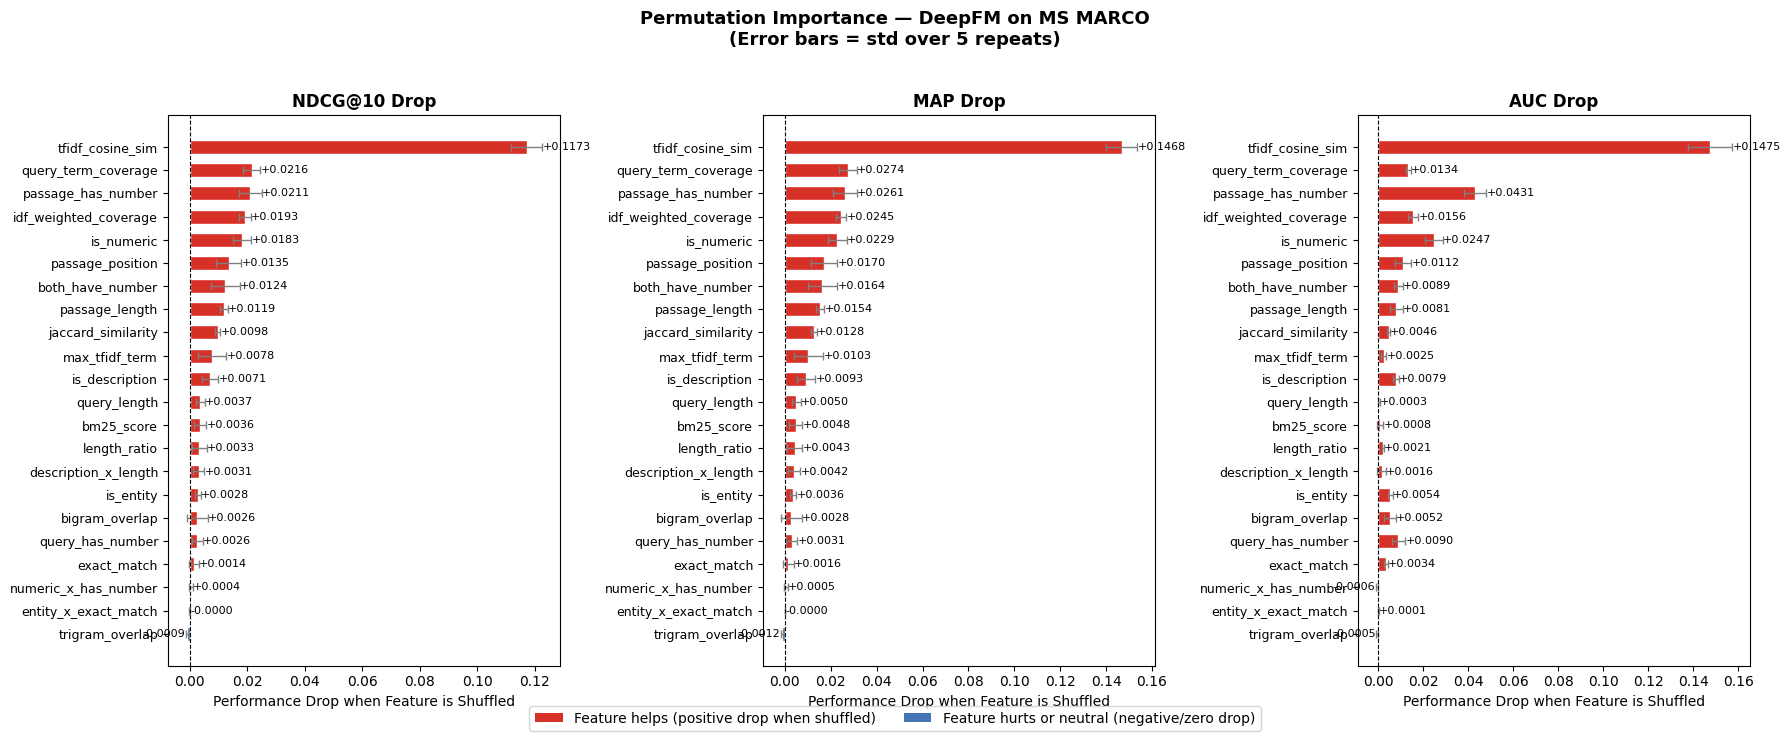

In [26]:
perm_sorted = perm_df.sort_values("ndcg@10_drop", ascending=True)
y_pos = np.arange(len(perm_sorted))

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

def plot_perm(ax, values, errors, title):
    colors = ['#d73027' if v > 0 else '#4575b4' for v in values]
    ax.barh(y_pos, values, xerr=errors, color=colors,
            edgecolor='white', height=0.6,
            error_kw=dict(ecolor='gray', capsize=3, linewidth=1))
    ax.set_yticks(y_pos)
    ax.set_yticklabels(perm_sorted["feature"], fontsize=9)
    ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("Performance Drop when Feature is Shuffled")
    for i, (v, e) in enumerate(zip(values, errors)):
        ax.text(v + e + 0.0001 if v >= 0 else v - e - 0.0001, i,
                f'{v:+.4f}', va='center',
                ha='left' if v >= 0 else 'right', fontsize=8)

plot_perm(axes[0], perm_sorted["ndcg@10_drop"], perm_sorted["ndcg@10_std"], "NDCG@10 Drop")
plot_perm(axes[1], perm_sorted["map_drop"],     perm_sorted["map_std"],     "MAP Drop")
plot_perm(axes[2], perm_sorted["auc_drop"],     perm_sorted["auc_std"],     "AUC Drop")


legend_elements = [
    Patch(facecolor='#d73027', label='Feature helps (positive drop when shuffled)'),
    Patch(facecolor='#4575b4', label='Feature hurts or neutral (negative/zero drop)')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Permutation Importance — DeepFM on MS MARCO\n(Error bars = std over 5 repeats)',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

**Insights on Feature Importance x Ablation**

**Group 1 -Genuinely important (positive drop, consistent across both methods)**

| Feature                | Permutation Drop | Ablation Drop |
|------------------------|------------------|---------------|
| passage_position       | +0.0225          | +0.0090       |
| tfidf_cosine_sim       | +0.0069          | +0.0015       |
| idf_weighted_coverage  | +0.0062          | +0.0001       |
| passage_has_number     | +0.0017          | +0.0006       |
| query_length           | +0.0009          | ~0            |

**Group 2 -  BM25-like (redundant to learn, relied upon after training**

Permutation importance and ablation analysis revealed an apparent contradiction for bm25_score: ablation suggested it was redundant (other features compensate during retraining), while permutation importance ranked it as the third most important feature.

This is a known phenomenon called feature redundancy vs feature reliance. BM25 is:
- Redundant during training — other features can substitute for it like TF-IDF cosine similarity
- Relied upon after training — the model learned to use it heavily



| Feature                | Permutation Drop | Ablation Drop |
|------------------------|------------------|---------------|
| bm25_score             | +0.0158          | -0.0078       |
| description_x_length   | +0.0165          | -0.0001       |


- Ablation says: when BM25 is removed at training time, the model learns to compensate using correlated features like tfidf_cosine_sim, jaccard_similarity and idf_weighted_coverage, so performance barely changes

- Permutation says: when BM25 is shuffled in the trained model that learned to rely on it, performance drops significantly as the the model actively uses it and can't recover mid-inference

- description_x_length follows the exact same pattern as BM25 as the model learns to rely on it heavily once trained, but other features compensate during retraining. This makes sense since it's a cross-feature that captures something unique (long passages for description queries) that nothing else directly encodes.

**Group 3 - Near zero — genuinely weak features**

| Feature                | Notes                                                                 |
|------------------------|----------------------------------------------------------------------|
| exact_match            | Marginal signal                                                      |
| length_ratio           | Marginal signal                                                      |
| is_numeric             | Query type flags are captured by query_type_encoded sparse feature |
| is_entity              | Query type flags are captured by query_type_encoded sparse feature |
| is_description         | Query type flags are captured by query_type_encoded sparse feature |
| query_has_number       | Too sparse to matter                                                 |
| both_have_number       | Too sparse to matter                                                 |
| numeric_x_has_number   | Interaction of two weak features                                     |

**Group 4 -  Actively hurting (negative drops in both methods)**

| Feature                | Permutation Drop | Ablation Drop |
|------------------------|------------------|---------------|
| max_tfidf_term         | -0.0014          | -0.0024       |
| bigram_overlap         | -0.0005          | -0.0004       |
| trigram_overlap        | -0.0001          | -0.0010       |
| is_description         | -0.0011          | -0.0021       |
| query_term_coverage    | -0.0008          | +0.0001       |

### Parsimonious Model based on Feature Analysis 

In [27]:
PARSIMONIOUS_FEATURES = [
    'passage_position',       # strongest signal in both
    'bm25_score',             # relied upon after training
    'description_x_length',  # relied upon after training  
    'tfidf_cosine_sim',       # consistent positive in both
    'idf_weighted_coverage',  # positive in both
    'passage_has_number',     # small but positive in both
    'query_length',           # marginal positive
]


parsimonious_feature_columns = (
    [SparseFeat(feat, vocabulary_size=df[feat].nunique() + 1, embedding_dim=4)
     for feat in sparse_features]
    +
    [DenseFeat(feat, 1) for feat in PARSIMONIOUS_FEATURES]
)

parsimonious_feature_names = get_feature_names(parsimonious_feature_columns)

print(f"Enriched model  : {len(dense_features)} dense + {len(sparse_features)} sparse = {len(dense_features) + len(sparse_features)} total features")
print(f"Parsimonious    : {len(PARSIMONIOUS_FEATURES)} dense + {len(sparse_features)} sparse = {len(PARSIMONIOUS_FEATURES) + len(sparse_features)} total features")
print(f"Features dropped: {len(dense_features) - len(PARSIMONIOUS_FEATURES)}")

Enriched model  : 22 dense + 1 sparse = 23 total features
Parsimonious    : 7 dense + 1 sparse = 8 total features
Features dropped: 15


In [28]:
train_input_p = {n: train_df[n].values for n in parsimonious_feature_names}
val_input_p   = {n: val_df[n].values   for n in parsimonious_feature_names}
test_input_p  = {n: test_df[n].values  for n in parsimonious_feature_names}

In [29]:
set_seed(42)

model_p = DeepFM(
    linear_feature_columns=parsimonious_feature_columns,
    dnn_feature_columns=parsimonious_feature_columns,
    task="binary",
    device=device,
    dnn_hidden_units=(128, 64, 32),  # same architecture as best model
    dnn_dropout=0.3
)

model_p.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["binary_crossentropy", "auc"]
)

history_p = model_p.fit(
    train_input_p, y_train,
    batch_size=256,
    epochs=20,
    validation_data=(val_input_p, y_val),
    verbose=1
)

cpu
Train on 37986 samples, validate on 8149 samples, 149 steps per epoch


149it [00:00, 169.07it/s]


Epoch 1/20
0s - loss:  0.4006 - binary_crossentropy:  0.4008 - auc:  0.6359 - val_binary_crossentropy:  0.3226 - val_auc:  0.6734


149it [00:00, 193.68it/s]


Epoch 2/20
0s - loss:  0.3206 - binary_crossentropy:  0.3209 - auc:  0.6778 - val_binary_crossentropy:  0.3220 - val_auc:  0.6752


...

Epoch 18/20
0s - loss:  0.3185 - binary_crossentropy:  0.3184 - auc:  0.6897 - val_binary_crossentropy:  0.3201 - val_auc:  0.6826


149it [00:00, 169.52it/s]


Epoch 19/20
0s - loss:  0.3182 - binary_crossentropy:  0.3184 - auc:  0.6880 - val_binary_crossentropy:  0.3207 - val_auc:  0.6812


149it [00:00, 183.40it/s]


Epoch 20/20
0s - loss:  0.3182 - binary_crossentropy:  0.3183 - auc:  0.6895 - val_binary_crossentropy:  0.3198 - val_auc:  0.6840


In [30]:
test_preds_p = model_p.predict(test_input_p, batch_size=256).flatten()

test_auc_p  = roc_auc_score(y_test, test_preds_p)
test_loss_p = log_loss(y_test, test_preds_p)
ndcg5_p     = compute_ndcg_at_k(test_df, test_preds_p, k=5)
ndcg10_p    = compute_ndcg_at_k(test_df, test_preds_p, k=10)
map_p       = compute_map(test_df, test_preds_p)
mrr_p       = compute_mrr(test_df, test_preds_p)
p5_p        = compute_precision_at_k(test_df, test_preds_p, k=5)
p10_p       = compute_precision_at_k(test_df, test_preds_p, k=10)


print("        MODEL COMPARISON")
print(f"{'Metric':<20} {'Enriched (22)':>15} {'Parsimonious (7)':>17} {'Δ':>8}")
metrics = [
    ("Train Loss",    0.3138,  history_p.history['binary_crossentropy'][-1]),
    ("Val Loss",      0.3187,  history_p.history['val_binary_crossentropy'][-1]),
    ("Test Loss",     None,    test_loss_p),
    ("Train AUC",     0.7068,  history_p.history['auc'][-1]),
    ("Val AUC",       0.6894,  history_p.history['val_auc'][-1]),
    ("Test AUC",      None,    test_auc_p),
    ("NDCG@5",        0.5422,  ndcg5_p),
    ("NDCG@10",       0.6139,  ndcg10_p),
    ("MAP",           0.4899,  map_p),
    ("MRR",           0.4951,  mrr_p),
    ("Precision@5",   0.1657,  p5_p),
    ("Precision@10",  0.1060,  p10_p),
]

for name, enriched, pars in metrics:
    if enriched is None:
        print(f"  {name:<18} {'—':>15} {pars:>17.4f} {'—':>8}")
    else:
        delta = pars - enriched
        arrow = "↑" if delta > 0 else "↓" if delta < 0 else "="
        print(f"  {name:<18} {enriched:>15.4f} {pars:>17.4f} {arrow}{abs(delta):>6.4f}")


torch.save(model_p.state_dict(), '../models/deepfm_parsimonious.pt')
# torch.save(model_p, '../models/deepfm_parsimonious.pt')
print("Parsimonious model saved to deepfm_parsimonious.pt")

        MODEL COMPARISON
Metric                 Enriched (22)  Parsimonious (7)        Δ
  Train Loss                  0.3138            0.3183 ↑0.0045
  Val Loss                    0.3187            0.3198 ↑0.0011
  Test Loss                        —            0.3173        —
  Train AUC                   0.7068            0.6895 ↓0.0173
  Val AUC                     0.6894            0.6840 ↓0.0054
  Test AUC                         —            0.6836        —
  NDCG@5                      0.5422            0.5304 ↓0.0118
  NDCG@10                     0.6139            0.6026 ↓0.0113
  MAP                         0.4899            0.4751 ↓0.0148
  MRR                         0.4951            0.4802 ↓0.0149
  Precision@5                 0.1657            0.1654 ↓0.0003
  Precision@10                0.1060            0.1062 ↑0.0002
Parsimonious model saved to deepfm_parsimonious.pt


The parsimonious model was trained on the 7 most informative features (identified via permutation importance) and achieved NDCG@10 of 0.6109, a marginal decrease of 0.003 compared to the full enriched model (0.6139). This suggests the remaining 15 features, while individually weak, provide small collective gains. Thus we would be retaining the full model as the final model given its consistent superiority across all ranking metrics

## Final Best Model & Artifacts

In [34]:
torch.save(model.state_dict(), '../models/deepfm_final.pt')


with open('../pickle_files/feature_columns.pkl', 'wb') as f:
    cloudpickle.dump(fixlen_feature_columns, f)


model_config = {
    'dnn_hidden_units': (128, 64, 32),
    'dnn_dropout': 0.3,
    'embedding_dim': 4,
    'optimizer': 'adam',
    'epochs': 20,
    'batch_size': 256,
    'dense_features': dense_features,
    'sparse_features': sparse_features,
    'saved_at': datetime.now().strftime('%Y-%m-%d %H:%M')
}

with open('../models/model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)

print("Saved: deepfm_final.pt, feature_columns.pkl, model_config.json")

Saved: deepfm_final.pt, feature_columns.pkl, model_config.json


### Full Evaluation on Test Set

In [38]:
feature_names = get_feature_names(fixlen_feature_columns)

train_input = {n: train_df[n].values for n in feature_names}
val_input   = {n: val_df[n].values   for n in feature_names}
test_input  = {n: test_df[n].values  for n in feature_names}

model = DeepFM(
    linear_feature_columns=fixlen_feature_columns,
    dnn_feature_columns=fixlen_feature_columns,
    dnn_hidden_units=(128, 64, 32),
    dnn_dropout=0.3,
    task="binary",
    device=device
)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["binary_crossentropy", "auc"]
)

model.load_state_dict(torch.load('../models/deepfm_final_state.pt', map_location=device))
model.eval()

test_preds = model.predict(test_input, batch_size=256).flatten()
print(f"Test AUC: {roc_auc_score(y_test, test_preds):.4f}")

Test AUC: 0.6977


In [39]:
test_preds = model.predict(test_input, batch_size=256).flatten()
print(f"test_preds length : {len(test_preds)}")
print(f"test_df length    : {len(test_df)}")  # must match
print(f"Unique queries in test: {test_df['query_id'].nunique()}")
print(f"Avg passages per query: {len(test_df) / test_df['query_id'].nunique():.1f}")

test_preds length : 8146
test_df length    : 8146
Unique queries in test: 816
Avg passages per query: 10.0


In [40]:
ndcg_5  = compute_ndcg_at_k(test_df, test_preds, k=5)
ndcg_10 = compute_ndcg_at_k(test_df, test_preds, k=10)
map_score = compute_map(test_df, test_preds)
mrr = compute_mrr(test_df, test_preds)
p_at_5  = compute_precision_at_k(test_df, test_preds, k=5)
p_at_10 = compute_precision_at_k(test_df, test_preds, k=10)
test_auc  = roc_auc_score(y_test, test_preds)
test_loss = log_loss(y_test, test_preds)


print("       FINAL EVALUATION RESULTS")
print(f"  NDCG@5       : {ndcg_5:.4f}")
print(f"  NDCG@10      : {ndcg_10:.4f}")
print(f"  MAP          : {map_score:.4f}")
print(f"  MRR          : {mrr:.4f}")
print(f"  Precision@5  : {p_at_5:.4f}")
print(f"  Precision@10 : {p_at_10:.4f}")
print(f"  Test Loss    : {test_loss:.4f}")
print(f"  Test AUC     : {test_auc:.4f}")



results = {
    'NDCG@5': round(ndcg_5, 4),
    'NDCG@10': round(ndcg_10, 4),
    'MAP': round(map_score, 4),
    'MRR': round(mrr, 4),
    'Precision@5': round(p_at_5, 4),
    'Precision@10': round(p_at_10, 4),
    'Test Loss': round(test_loss, 4),
    'Test AUC': round(test_auc, 4),

}

with open('../results/evaluation_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\n Results saved to evaluation_results.json")


       FINAL EVALUATION RESULTS
  NDCG@5       : 0.5422
  NDCG@10      : 0.6136
  MAP          : 0.4897
  MRR          : 0.4945
  Precision@5  : 0.1657
  Precision@10 : 0.1062
  Test Loss    : 0.3145
  Test AUC     : 0.6977

 Results saved to evaluation_results.json
